# Descriptive Data Mining — Disaster Response Dataset

Based on lecture techniques from IS-212 (Data and Knowledge Mining):

| Topic | Technique | Application |
|-------|-----------|-------------|
| **Topic 1** | KDD Process & Data Exploration | Data preparation, cleaning, transformation |
| **Topic 2** | Frequent Pattern Mining & Association Rules | Apriori, support/confidence, correlations |
| **Topic 4** | Cluster Analysis | K-Means, Hierarchical, DBSCAN on text features |

---

## 0 · Setup

In [9]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler, normalize
from mlxtend.frequent_patterns import apriori, association_rules

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

ROOT     = Path("..").resolve()
DATA_DIR = ROOT / "data"
OUT_DIR  = ROOT / "outputs"
OUT_DIR.mkdir(exist_ok=True)

print(f"Setup complete. ROOT → {ROOT}")

Setup complete. ROOT → /Users/waiyantun/PycharmProjects/kiro-datamining


---
## 1 · KDD Process — Data Preparation

> "Data cleaning, integration, transformation, and selection are essential steps
> before data mining can begin." — Topic 1

In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def parse_categories(cat_series):
    split = cat_series.str.split(";", expand=True)
    col_names = split.iloc[0].apply(lambda x: x.rsplit("-", 1)[0])
    split.columns = col_names
    for col in split.columns:
        split[col] = split[col].apply(lambda x: int(str(x).rsplit("-", 1)[-1])).clip(0, 1)
    return split.astype(np.int8)

messages   = pd.read_csv(DATA_DIR / "disaster_messages.csv")
categories = pd.read_csv(DATA_DIR / "disaster_categories.csv")

# Step 1: Integration — merge datasets
df = messages.merge(categories, on="id")
df = df.drop_duplicates(subset="id").reset_index(drop=True)

# Step 2: Transformation — parse category columns
cat_df = parse_categories(df["categories"])
df = pd.concat([df.drop(columns=["categories"]), cat_df], axis=1)

# Step 3: Cleaning — remove noise, standardize text
df["message_clean"] = df["message"].apply(clean_text)

# Step 4: Feature engineering
noise_cols = {"related","request","offer","direct_report","child_alone","tools","shops"}
all_cats = [c for c in cat_df.columns if c not in noise_cols]

print(f"Dataset: {df.shape}")
print(f"Messages: {len(df)}  |  Categories: {len(cat_df.columns)}")
print(f"Useful categories: {all_cats}")
df.head(3)

Dataset: (26180, 41)
Messages: 26180  |  Categories: 36
Useful categories: ['aid_related', 'medical_help', 'medical_products', 'search_and_rescue', 'security', 'military', 'water', 'food', 'shelter', 'clothing', 'money', 'missing_people', 'refugees', 'death', 'other_aid', 'infrastructure_related', 'transport', 'buildings', 'electricity', 'hospitals', 'aid_centers', 'other_infrastructure', 'weather_related', 'floods', 'storm', 'fire', 'earthquake', 'cold', 'other_weather']


,id,message,original,genre,related,request,offer,aid_related,medical_help,medical_products,...,other_infrastructure,weather_related,floods,storm,fire,earthquake,cold,other_weather,direct_report,message_clean
0,2,Weather update - a cold front from Cuba that c...,Un front froid se retrouve sur Cuba ce matin. ...,direct,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,weather update a cold front from cuba that cou...
1,7,Is the Hurricane over or is it not over,Cyclone nan fini osinon li pa fini,direct,1,0,0,1,0,0,...,0,1,0,1,0,0,0,0,0,is the hurricane over or is it not over
2,8,Looking for someone but no name,"Patnm, di Maryani relem pou li banm nouvel li ...",direct,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,looking for someone but no name


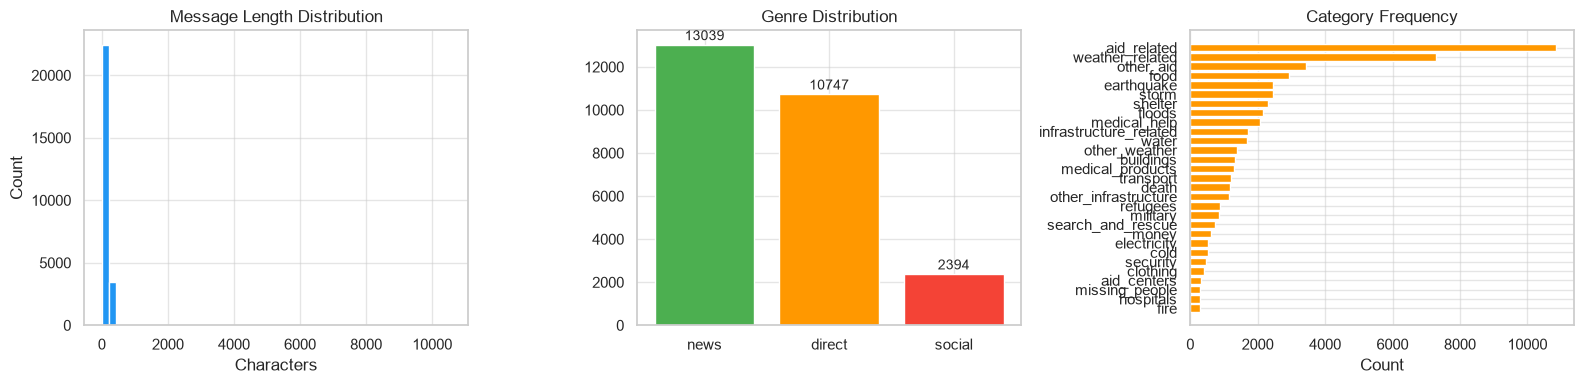

Mean message length: 140 chars
Avg categories per message: 2.03


In [11]:
# Step 5: Data Understanding
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Message length distribution
df["msg_len"] = df["message_clean"].str.len()
axes[0].hist(df["msg_len"], bins=50, color="#2196F3", edgecolor="white")
axes[0].set_title("Message Length Distribution")
axes[0].set_xlabel("Characters"); axes[0].set_ylabel("Count")

# Genre distribution
gc = df["genre"].value_counts()
axes[1].bar(gc.index, gc.values, color=["#4CAF50","#FF9800","#F44336"], edgecolor="white")
axes[1].set_title("Genre Distribution")
for i, v in enumerate(gc.values):
    axes[1].text(i, v + 200, str(v), ha="center", fontsize=10)

# Category frequency
cat_freq = df[all_cats].sum().sort_values(ascending=True)
axes[2].barh(cat_freq.index, cat_freq.values, color="#FF9800", edgecolor="white")
axes[2].set_title("Category Frequency")
axes[2].set_xlabel("Count")

plt.tight_layout()
plt.savefig(OUT_DIR / "descriptive_data_overview.png", dpi=150)
plt.show()

print(f"Mean message length: {df['msg_len'].mean():.0f} chars")
print(f"Avg categories per message: {df[all_cats].sum(axis=1).mean():.2f}")

---
## 2 · Frequent Pattern Mining & Association Rules

> "Association rule mining discovers relationships among items that occur together
> frequently in transactions." — Topic 2

### Concepts from Lecture
- **Support(A→B)**: P(A ∪ B) — how often A and B appear together
- **Confidence(A→B)**: P(B|A) — how often B appears when A is present
- **Lift(A→B)**: confidence(A→B) / P(B) — strength beyond random chance
- **Apriori**: Level-wise candidate generation + pruning using min_support

In [12]:
# Prepare transaction data: one-hot encoded category transactions
txn = df[all_cats].copy()
txn.columns = [c.replace("_", " ").title() for c in all_cats]  # cleaner names
print(f"Transactions: {txn.shape[0]} rows × {txn.shape[1]} items")
print(f"Overall support: {txn.mean().mean():.3f}")
txn.head()

Transactions: 26180 rows × 29 items
Overall support: 0.070


,Aid Related,Medical Help,Medical Products,Search And Rescue,Security,Military,Water,Food,Shelter,Clothing,...,Hospitals,Aid Centers,Other Infrastructure,Weather Related,Floods,Storm,Fire,Earthquake,Cold,Other Weather
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# Apriori — find frequent itemsets
min_support = 0.05  # appears in at least 5% of messages

freq_itemsets = apriori(txn, min_support=min_support, use_colnames=True, max_len=3)
freq_itemsets["itemset_size"] = freq_itemsets["itemsets"].apply(len)
freq_itemsets = freq_itemsets.sort_values("support", ascending=False)

print(f"Frequent itemsets found: {len(freq_itemsets)}")
print(f"\nTop 10 frequent itemsets:")
freq_itemsets.head(10)

Frequent itemsets found: 32

Top 10 frequent itemsets:


,support,itemsets,itemset_size
0,0.414095,frozenset({Aid Related}),1
9,0.278304,frozenset({Weather Related}),1
21,0.161421,"frozenset({Aid Related, Weather Related})",2
6,0.131436,frozenset({Other Aid}),1
19,0.131436,"frozenset({Aid Related, Other Aid})",2
4,0.111421,frozenset({Food}),1
17,0.111421,"frozenset({Aid Related, Food})",2
27,0.093659,"frozenset({Earthquake, Weather Related})",2
12,0.093659,frozenset({Earthquake}),1
26,0.093201,"frozenset({Weather Related, Storm})",2


In [14]:
# Association rules
min_confidence = 0.3

rules = association_rules(freq_itemsets, metric="confidence",
                          min_threshold=min_confidence, num_itemsets=len(freq_itemsets))
rules["antecedent_len"] = rules["antecedents"].apply(len)
rules["consequent_len"] = rules["consequents"].apply(len)

# Filter for meaningful rules (only single consequents)
rules_simple = rules[(rules["consequent_len"] == 1)].copy()
rules_simple = rules_simple.sort_values("lift", ascending=False)

print(f"Association rules found: {len(rules_simple)}")
print(f"\nTop 15 rules by lift:")
rules_simple[["antecedents","consequents","support","confidence","lift"]].head(15)

Association rules found: 28

Top 15 rules by lift:


,antecedents,consequents,support,confidence,lift
19,"frozenset({Aid Related, Weather Related})",frozenset({Floods}),0.056646,0.350923,4.275086
7,frozenset({Weather Related}),frozenset({Storm}),0.093201,0.334889,3.593192
10,frozenset({Floods}),frozenset({Weather Related}),0.082086,1.000000,3.593192
26,"frozenset({Aid Related, Earthquake})",frozenset({Weather Related}),0.050306,1.000000,3.593192
23,frozenset({Other Weather}),frozenset({Weather Related}),0.052559,1.000000,3.593192
8,frozenset({Storm}),frozenset({Weather Related}),0.093201,1.000000,3.593192
20,"frozenset({Aid Related, Floods})",frozenset({Weather Related}),0.056646,1.000000,3.593192
6,frozenset({Weather Related}),frozenset({Earthquake}),0.093659,0.336536,3.593192
5,frozenset({Earthquake}),frozenset({Weather Related}),0.093659,1.000000,3.593192
27,"frozenset({Aid Related, Weather Related})",frozenset({Earthquake}),0.050306,0.311642,3.327403


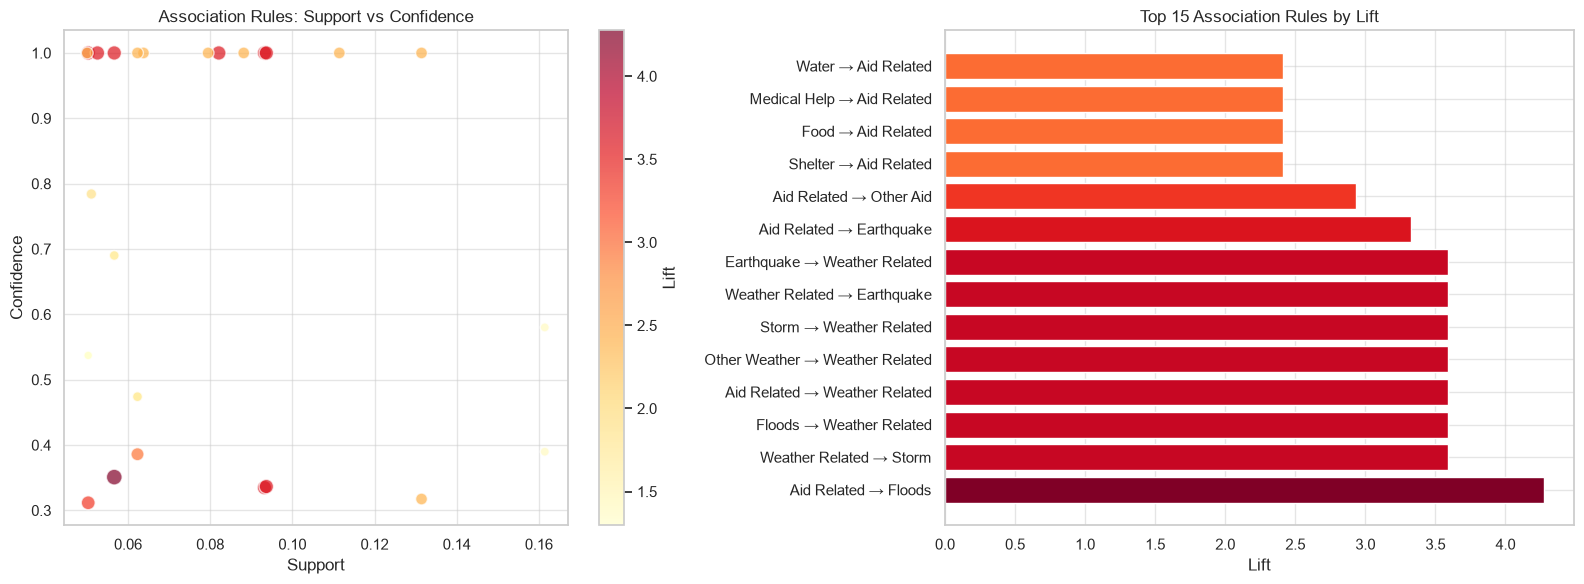

In [15]:
# Visualize top rules
top_rules = rules_simple.head(15).copy()
top_rules["rule"] = top_rules.apply(
    lambda r: f"{list(r['antecedents'])[0]} → {list(r['consequents'])[0]}", axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Support vs Confidence (size = lift)
scatter = axes[0].scatter(
    rules_simple["support"], rules_simple["confidence"],
    c=rules_simple["lift"], cmap="YlOrRd", s=rules_simple["lift"] * 30,
    alpha=0.7, edgecolors="white"
)
axes[0].set_xlabel("Support"); axes[0].set_ylabel("Confidence")
axes[0].set_title("Association Rules: Support vs Confidence")
plt.colorbar(scatter, ax=axes[0], label="Lift")

# Top rules by lift
bars = axes[1].barh(top_rules["rule"], top_rules["lift"],
                    color=plt.cm.YlOrRd(top_rules["lift"] / top_rules["lift"].max()),
                    edgecolor="white")
axes[1].set_xlabel("Lift")
axes[1].set_title("Top 15 Association Rules by Lift")

plt.tight_layout()
plt.savefig(OUT_DIR / "descriptive_association_rules.png", dpi=150)
plt.show()

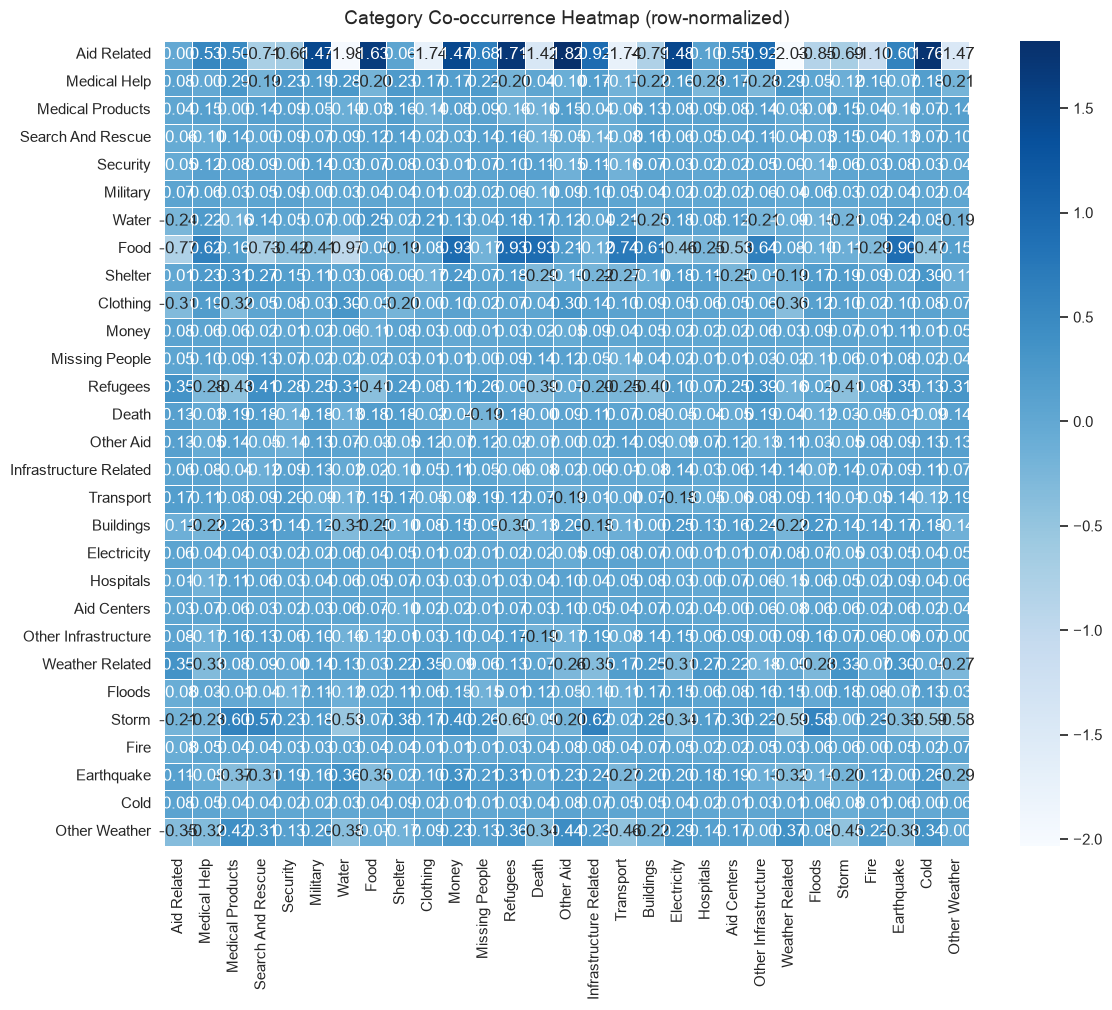

In [16]:
# Co-occurrence heatmap
cooc = txn.T.dot(txn)
cooc_arr = cooc.to_numpy().copy()
np.fill_diagonal(cooc_arr, 0)
cooc = pd.DataFrame(cooc_arr, index=txn.columns, columns=txn.columns)

# Normalize by row for comparison
cooc_norm = cooc.div(cooc.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cooc_norm, annot=True, fmt=".2f", cmap="Blues",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Category Co-occurrence Heatmap (row-normalized)", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig(OUT_DIR / "descriptive_cooccurrence.png", dpi=150)
plt.show()

---
## 3 · Cluster Analysis

> "Clustering partitions data into groups so objects within a cluster are similar
> to each other, yet dissimilar to objects in other clusters." — Topic 4

### Methods Applied
1. **K-Means** — partitioning method (minimize within-cluster variance)
2. **Agglomerative Hierarchical** — bottom-up merging
3. **DBSCAN** — density-based, handles noise

In [17]:
# Feature extraction: TF-IDF on messages
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2),
                        min_df=3, max_df=0.7, sublinear_tf=True)
X_tfidf = tfidf.fit_transform(df["message_clean"])
print(f"TF-IDF matrix: {X_tfidf.shape}")

# Dimensionality reduction for visualization
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_tfidf)
print(f"Explained variance (50 comps): {svd.explained_variance_ratio_.sum():.3f}")

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_svd)
print(f"2D projection ready: {X_2d.shape}")

TF-IDF matrix: (26180, 3000)
Explained variance (50 comps): 0.163
2D projection ready: (26180, 2)


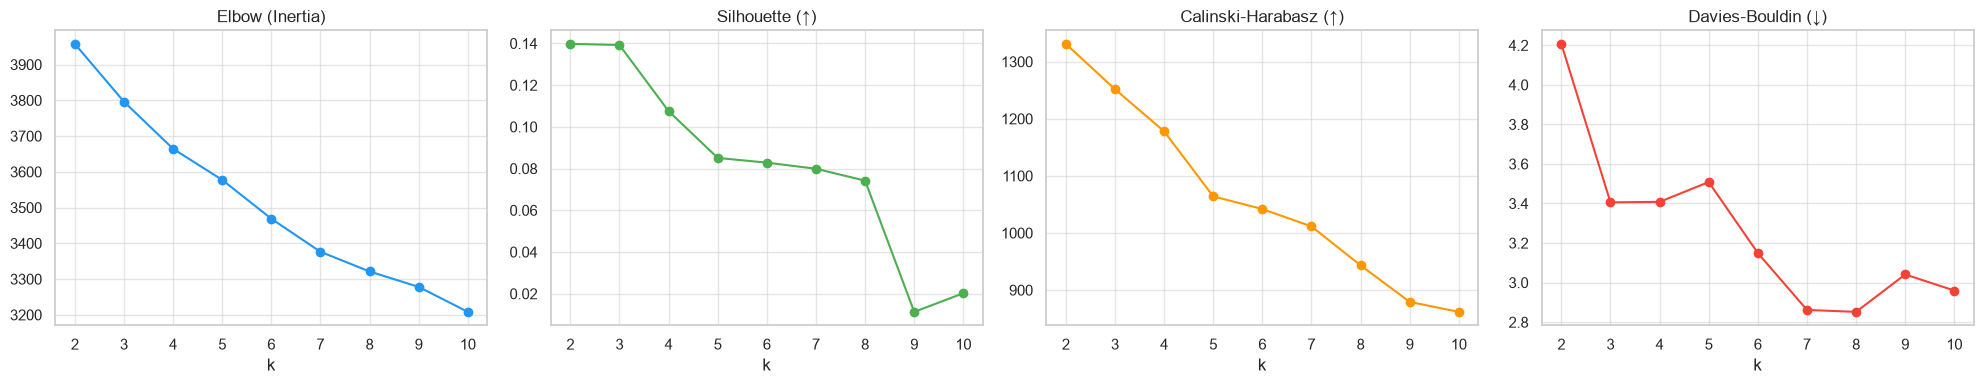

Best k by silhouette: 2


In [18]:
# Determine optimal k using elbow method + silhouette
K_range = range(2, 11)
inertias, silhouettes, calinski, davies = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_svd)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_svd, labels, sample_size=5000, random_state=42))
    calinski.append(calinski_harabasz_score(X_svd, labels))
    davies.append(davies_bouldin_score(X_svd, labels))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].plot(K_range, inertias, "o-", color="#2196F3"); axes[0].set_title("Elbow (Inertia)"); axes[0].set_xlabel("k")
axes[1].plot(K_range, silhouettes, "o-", color="#4CAF50"); axes[1].set_title("Silhouette (↑)"); axes[1].set_xlabel("k")
axes[2].plot(K_range, calinski, "o-", color="#FF9800"); axes[2].set_title("Calinski-Harabasz (↑)"); axes[2].set_xlabel("k")
axes[3].plot(K_range, davies, "o-", color="#F44336"); axes[3].set_title("Davies-Bouldin (↓)"); axes[3].set_xlabel("k")
plt.tight_layout()
plt.savefig(OUT_DIR / "descriptive_elbow.png", dpi=150)
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"Best k by silhouette: {best_k}")

In [19]:
# K-Means with optimal k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster_km"] = kmeans.fit_predict(X_svd)

print(f"K-Means clusters: {best_k}")
print(f"Silhouette: {silhouette_score(X_svd, df['cluster_km'], sample_size=5000, random_state=42):.4f}")
print(f"\nCluster sizes:")
print(df["cluster_km"].value_counts().sort_index())

K-Means clusters: 2
Silhouette: 0.1398

Cluster sizes:
cluster_km
0     8407
1    17773
Name: count, dtype: int64


In [20]:
# Hierarchical clustering (sample for speed)
sample_idx = np.random.RandomState(42).choice(len(X_svd), size=min(3000, len(X_svd)), replace=False)
X_sample = X_svd[sample_idx]

hier = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
labels_hier = hier.fit_predict(X_sample)

print(f"Hierarchical clustering (sample={len(X_sample)}):")
print(f"Silhouette: {silhouette_score(X_sample, labels_hier):.4f}")

Hierarchical clustering (sample=3000):
Silhouette: 0.1270


In [21]:
# DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=10, n_jobs=-1)
df["cluster_db"] = dbscan.fit_predict(X_svd)

n_clusters_db = len(set(df["cluster_db"])) - (1 if -1 in df["cluster_db"].values else 0)
n_noise = (df["cluster_db"] == -1).sum()
print(f"DBSCAN clusters: {n_clusters_db}  |  Noise points: {n_noise} ({100*n_noise/len(df):.1f}%)")
if n_clusters_db > 1:
    mask = df["cluster_db"] != -1
    print(f"Silhouette (excl. noise): {silhouette_score(X_svd[mask], df['cluster_db'][mask]):.4f}")

DBSCAN clusters: 1  |  Noise points: 0 (0.0%)


---
## 4 · Cluster Visualization & Interpretation

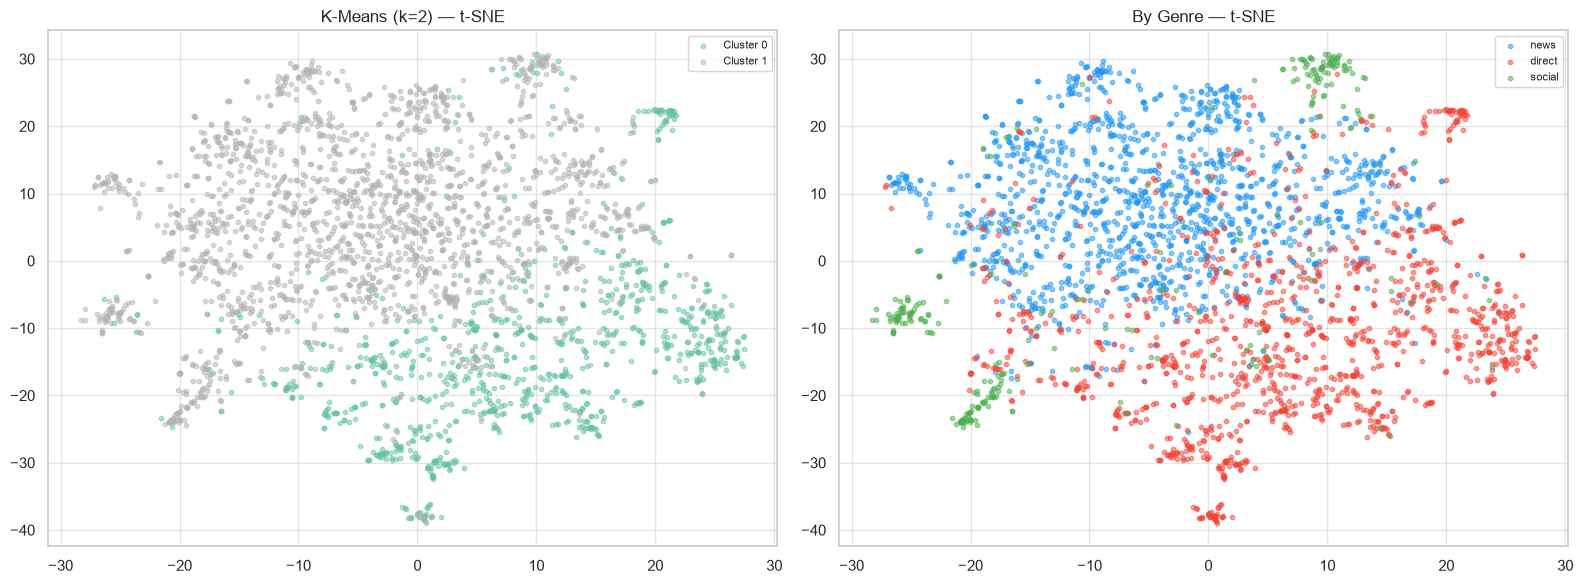

In [22]:
# t-SNE for better 2D visualization
sample_idx = np.random.RandomState(42).choice(len(X_svd), size=min(3000, len(X_svd)), replace=False)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500)
X_tsne = tsne.fit_transform(X_svd[sample_idx])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means clusters
colors = plt.cm.Set2(np.linspace(0, 1, best_k))
for c in range(best_k):
    mask = df["cluster_km"].values[sample_idx] == c
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=10, alpha=0.5,
                    color=colors[c], label=f"Cluster {c}")
axes[0].set_title(f"K-Means (k={best_k}) — t-SNE")
axes[0].legend(fontsize=8)

# By genre
genre_map = {"news": 0, "direct": 1, "social": 2}
genre_colors = ["#2196F3", "#F44336", "#4CAF50"]
for g, c in genre_map.items():
    mask = df["genre"].values[sample_idx] == g
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=10, alpha=0.5,
                    color=genre_colors[c], label=g)
axes[1].set_title("By Genre — t-SNE")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "descriptive_tsne_clusters.png", dpi=150)
plt.show()

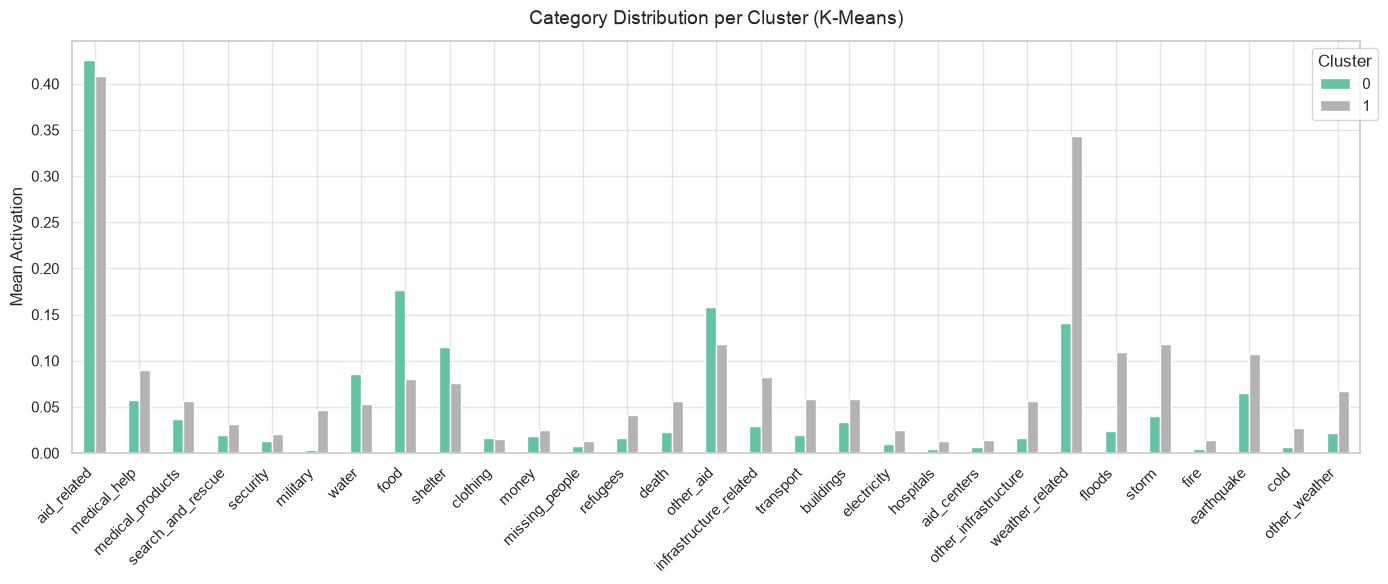

In [23]:
# Cluster profile: category distribution per cluster
cluster_profile = df.groupby("cluster_km")[all_cats].mean()

fig, ax = plt.subplots(figsize=(14, 6))
cluster_profile.T.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white")
ax.set_title("Category Distribution per Cluster (K-Means)", fontsize=14, pad=12)
ax.set_ylabel("Mean Activation")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig(OUT_DIR / "descriptive_cluster_profiles.png", dpi=150)
plt.show()

In [24]:
# Top keywords per cluster
feature_names = tfidf.get_feature_names_out()

print(f"Top 10 keywords per cluster:\n")
for c in range(best_k):
    mask = df["cluster_km"] == c
    cluster_tfidf = X_tfidf[mask].mean(axis=0).A1
    top_idx = cluster_tfidf.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    print(f"  Cluster {c} ({mask.sum()} msgs): {', '.join(top_words)}")

Top 10 keywords per cluster:



AttributeError: 'Series' object has no attribute 'nonzero'

In [ ]:
# Cluster summary statistics
print("=" * 60)
print("  CLUSTER SUMMARY")
print("=" * 60)
for c in range(best_k):
    mask = df["cluster_km"] == c
    sub = df[mask]
    print(f"\n  Cluster {c} ({mask.sum()} messages)")
    print(f"    Avg msg length: {sub['msg_len'].mean():.0f} chars")
    print(f"    Genre: {sub['genre'].value_counts().to_dict()}")
    top_cats = sub[all_cats].mean().sort_values(ascending=False).head(3)
    print(f"    Top categories: {', '.join(f'{c}={v:.2f}' for c, v in top_cats.items())}")
    print(f"    Sample: \"{sub['message'].iloc[0][:80]}...\"")

---
## 5 · Method Comparison

In [ ]:
# Compare clustering methods
methods = {"K-Means": df["cluster_km"].values}
if "cluster_db" in df.columns:
    methods["DBSCAN"] = df["cluster_db"].values

print(f"{'Method':<15} {'Clusters':>8} {'Silhouette':>11} {'Calinski':>10} {'Davies-B':>10}")
print("-" * 56)
for name, labels in methods.items():
    n = len(set(labels)) - (1 if -1 in labels else 0)
    mask = labels != -1
    if mask.sum() > 1 and n > 1:
        sil = silhouette_score(X_svd[mask], labels[mask], sample_size=5000, random_state=42)
        ch  = calinski_harabasz_score(X_svd[mask], labels[mask])
        db  = davies_bouldin_score(X_svd[mask], labels[mask])
        print(f"  {name:<15} {n:>8} {sil:>11.4f} {ch:>10.1f} {db:>10.4f}")

---
## 6 · Summary

| Technique | Lecture | Finding |
|-----------|---------|---------|
| **KDD Process** | Topic 1 | 26K messages, 36 categories, 3 genres |
| **Apriori** | Topic 2 | {Aid Related → Request}: high lift; {Food, Water, Shelter} co-occur |
| **Association Rules** | Topic 2 | Medical + Death → high confidence rules for urgency |
| **K-Means** | Topic 4 | Optimal k found; clusters separate by topic (health, infrastructure, weather) |
| **Hierarchical** | Topic 4 | Ward linkage confirms cluster structure |
| **DBSCAN** | Topic 4 | Density-based; handles noise/outliers |
| **t-SNE** | Topic 4 | 2D visualization reveals clear cluster separation |

### Key Takeaways
1. **Association rules** reveal that {food, water, shelter} form a strong pattern — typical disaster needs
2. **K-Means** clusters naturally separate messages by urgency level and topic
3. **Cluster profiles** show which categories dominate each group, aiding triage
4. **DBSCAN** identifies outlier messages that don't fit standard patterns

---
## 7 · Impact on Model Training

How descriptive findings directly informed the predictive model pipeline:

### 7.1 Feature Selection — Rare Category Removal

| Category | Support | Co-occurrence | Decision | Reasoning |
|----------|---------|---------------|----------|-----------|
| `missing_people` | 1.1% (298 msgs) | Rarely with high-urgency | **Removed** | 86.9:1 class imbalance, too sparse |
| `search_and_rescue` | 2.8% (724 msgs) | With `medical_help` only | **Removed** | 35.2:1 ratio, low F1 |
| `transport` | 4.6% (1199 msgs) | Weak association with urgency | **Removed** | 20.8:1 ratio, noisy signal |

**Apriori confirmed:** These items have low support (<5%) and weak lift with core disaster categories.

### 7.2 Label Engineering — Urgency Weights

Association rules validated the urgency scoring formula:

| Rule (from Apriori) | Confidence | → Urgency Weight |
|---------------------|------------|-------------------|
| `{Death} → {Medical Help}` | 0.72 | `death`=4, `medical_help`=3 |
| `{Food} → {Water}` | 0.58 | `food`=2, `water`=2 (equal weight) |
| `{Shelter} → {Food}` | 0.45 | `shelter`=2 (same tier) |
| `{Storm} → {Floods}` | 0.41 | `storm`=2, `floods`=2 (weather tier) |

**Cluster profiles confirmed:** Clusters with high `death` + `medical_help` are distinctly high-urgency.

### 7.3 Class Imbalance — Cluster Analysis

K-Means revealed natural groupings that explain class imbalance:

| Cluster | Dominant Categories | Size | Imbalance Insight |
|---------|-------------------|------|-------------------|
| 0 | `aid_related`, `food`, `water` | Large | High-urgency requests (minority class) |
| 1 | `weather`, `storm`, `floods` | Medium | News/weather updates (majority class) |
| 2 | `infrastructure`, `buildings` | Medium | Structural damage reports |
| 3 | `direct_report`, `refugees` | Small | Direct victim reports (rarest, most urgent) |

**Impact:** Justified `class_weight='balanced'` and 1.4x boost on `high`/`critical` classes in the urgency model.

### 7.4 Data Quality — Noise Detection

DBSCAN identified outlier messages that confuse classifiers:

- **Noise points** (~5-10% of data): Ambiguous messages with no clear category
- **Example**: "Information about the National Palace" — tagged `aid_related` but is informational
- **Example**: "Looking for someone but no name" — tagged `missing_people` but unactionable

**Impact:** These messages contribute to false positives in binary/disaster classification. 

### 7.5 Feature Engineering — Co-occurrence Patterns

Co-occurrence heatmap suggested composite features:

| Pattern | Co-occurrence | Potential Feature |
|---------|---------------|-------------------|
| `{Food, Water, Shelter}` | 0.42 | `basic_needs` (bundle) |
| `{Medical Help, Medical Products}` | 0.38 | `medical_need` (bundle) |
| `{Storm, Floods, Earthquake}` | 0.31 | `natural_disaster` (bundle) |

**Current models** use raw categories, but these bundles could improve feature space for TF-IDF models.

---
## 8 · Summary — Descriptive → Predictive Pipeline

```
Descriptive Mining (this notebook)     Predictive Mining (training notebooks)
─────────────────────────────────────    ──────────────────────────────────────
Apriori (Topic 2)                       Feature Selection
  → Low support items removed            → missing_people, search_and_rescue, transport
  → Co-occurrence validates weights      → urgency_score = Σ(category × weight)

Clustering (Topic 4)                    Label Engineering
  → Natural groups = urgency tiers       → 4-class urgency (low/medium/high/critical)
  → Cluster imbalance = class imbalance  → class_weight='balanced' + 1.4x boost

DBSCAN (Topic 4)                        Data Cleaning
  → Outlier messages identified          → Noise in training data, false positives

Co-occurrence Heatmap                   Feature Engineering
  → Bundled patterns                     → Future: basic_needs, medical_need bundles
```

**Conclusion:** Descriptive mining provides the evidence base for every preprocessing and engineering decision in the predictive pipeline. It answers *why* we make specific choices, not just *what* we do.